In [1]:
# =============================================================================
# GAN-vs-GAN IDS PROJECT — Data Preprocessing
# Dataset: CICIDS 2017 (MachineLearningCSV.zip)
# Author: [Rishi] — Data Preprocessing Module
# Team role: Provides clean train/val/test splits + TimeGAN sequences
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ─────────────────────────────────────────────────────────────────────────────
!pip install imbalanced-learn -q

# ─────────────────────────────────────────────────────────────────────────────

In [2]:
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Step 1: Unzip and load all CSVs
# ─────────────────────────────────────────────────────────────────────────────

ZIP_PATH = '/content/MachineLearningCSV.zip'
EXTRACT_DIR = '/content/CICIDS2017'

# Unzip
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
    print("Extracted files:")
    print('\n'.join(z.namelist()))

# Find all CSVs (they may be in a subfolder)
csv_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print(f"\nFound {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  {f}")

# Load and concatenate all CSVs
dfs = []
for f in csv_files:
    print(f"\nLoading {os.path.basename(f)}...")
    tmp = pd.read_csv(f, encoding='utf-8', low_memory=False)
    print(f"  Shape: {tmp.shape}")
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"\n✓ Merged dataset shape: {df.shape}")

Extracted files:
MachineLearningCVE/
MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Found 8 CSV files:
  /content/CICIDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  /content/CICIDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
  /content/CICIDS2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  /content/CICIDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
  /content/CICIDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_IS

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Step 2: Fix column names
# CICIDS 2017 columns have leading/trailing spaces — this breaks everything
# ─────────────────────────────────────────────────────────────────────────────

print("Columns BEFORE stripping:")
print(df.columns.tolist()[:5], "...")

# Strip whitespace from all column names
df.columns = df.columns.str.strip()

# The label column is called ' Label' or 'Label' depending on the file
# After stripping it should be 'Label' — verify:
assert 'Label' in df.columns, f"Label column not found! Columns: {df.columns.tolist()}"
print("\n✓ Column names cleaned. Label column found.")
print(f"Unique labels: {df['Label'].unique()}")

Columns BEFORE stripping:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets'] ...

✓ Column names cleaned. Label column found.
Unique labels: ['BENIGN' 'Infiltration' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'Bot' 'DoS slowloris' 'DoS Slowhttptest'
 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'DDoS' 'PortScan' 'FTP-Patator'
 'SSH-Patator']


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Step 3: Clean the data
# CICIDS 2017 has known issues: Inf values, NaNs, duplicate rows
# ─────────────────────────────────────────────────────────────────────────────

print(f"Shape before cleaning: {df.shape}")

# 3a. Replace Inf and -Inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3b. Drop rows with any NaN
nan_count = df.isnull().sum().sum()
print(f"NaN values found: {nan_count}")
df.dropna(inplace=True)
print(f"Shape after dropping NaN: {df.shape}")

# 3c. Drop fully duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

# 3d. Separate features and label
X = df.drop(columns=['Label'])
y = df['Label']

# 3e. Drop any non-numeric columns (e.g. if a flow ID column slipped in)
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Dropping non-numeric columns: {non_numeric}")
    X.drop(columns=non_numeric, inplace=True)

print(f"\n✓ Clean feature matrix: {X.shape}")
print(f"✓ Label series: {y.shape}")

Shape before cleaning: (2830743, 79)
NaN values found: 5734
Shape after dropping NaN: (2827876, 79)
Duplicate rows found: 307078
Shape after dropping duplicates: (2520798, 79)

✓ Clean feature matrix: (2520798, 78)
✓ Label series: (2520798,)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Step 4: Encode labels
# Map multi-class labels → integers AND binary (BENIGN=0, ATTACK=1)
# Your team needs BOTH: multi-class for full IDS, binary for GAN training
# ─────────────────────────────────────────────────────────────────────────────

# Multi-class encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping (multi-class):")
for i, cls in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f"  {i:2d} → {cls:<40s} count: {count:>8,}")

# Binary encoding: BENIGN = 0, any attack = 1
y_binary = (y != 'BENIGN').astype(int)
print(f"\nBinary split:")
print(f"  BENIGN (0): {(y_binary == 0).sum():,}")
print(f"  ATTACK (1): {(y_binary == 1).sum():,}")

# Save the encoder — teammates need this to decode predictions
with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("\n✓ label_encoder.pkl saved")

Label mapping (multi-class):
   0 → BENIGN                                   count: 2,095,057
   1 → Bot                                      count:    1,948
   2 → DDoS                                     count:  128,014
   3 → DoS GoldenEye                            count:   10,286
   4 → DoS Hulk                                 count:  172,846
   5 → DoS Slowhttptest                         count:    5,228
   6 → DoS slowloris                            count:    5,385
   7 → FTP-Patator                              count:    5,931
   8 → Heartbleed                               count:       11
   9 → Infiltration                             count:       36
  10 → PortScan                                 count:   90,694
  11 → SSH-Patator                              count:    3,219
  12 → Web Attack � Brute Force                 count:    1,470
  13 → Web Attack � Sql Injection               count:       21
  14 → Web Attack � XSS                         count:      652

Binary sp

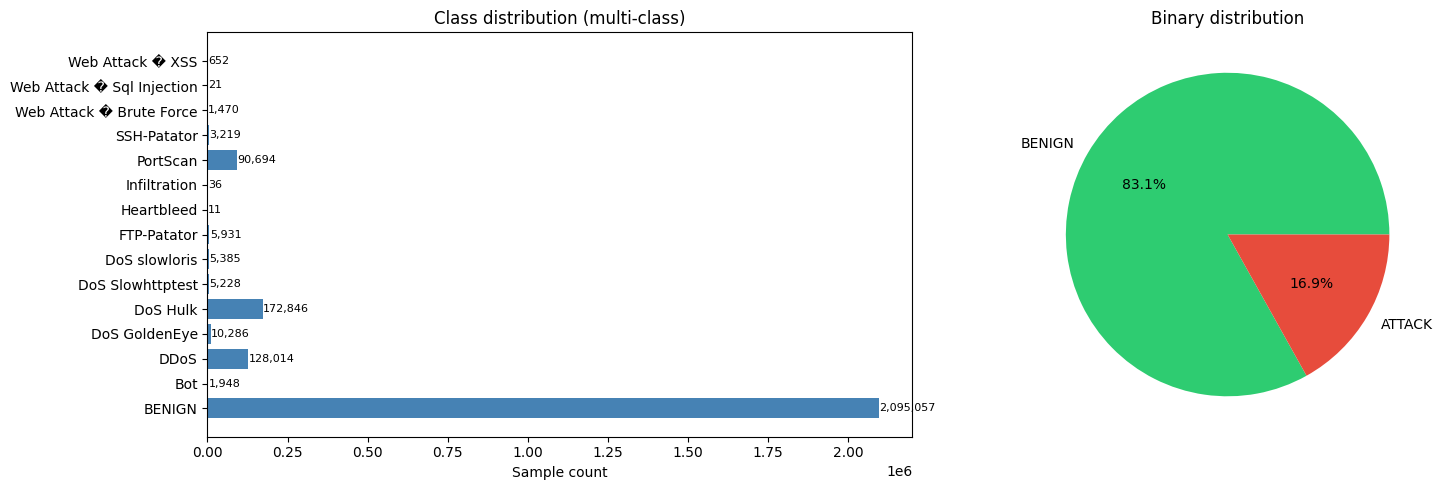

✓ class_distribution.png saved


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Step 5: Class distribution plot (EDA)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Multi-class bar chart
class_counts = pd.Series(y_encoded).value_counts().sort_index()
class_names = [le.classes_[i] for i in class_counts.index]
axes[0].barh(class_names, class_counts.values, color='steelblue')
axes[0].set_xlabel('Sample count')
axes[0].set_title('Class distribution (multi-class)')
for i, v in enumerate(class_counts.values):
    axes[0].text(v + 1000, i, f'{v:,}', va='center', fontsize=8)

# Binary pie chart
binary_counts = y_binary.value_counts()
axes[1].pie(binary_counts, labels=['BENIGN', 'ATTACK'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Binary distribution')

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ class_distribution.png saved")


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Step 6: Feature engineering
# Remove zero-variance and near-zero-variance features
# They carry no information and can break GAN training
# ─────────────────────────────────────────────────────────────────────────────

print(f"Features before variance filtering: {X.shape[1]}")

# Remove constant columns (zero variance)
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X)
removed_const = X.shape[1] - X_vt.shape[1]
print(f"Removed {removed_const} constant features")

# Get surviving feature names
feature_names = X.columns[vt.get_support()].tolist()
X = pd.DataFrame(X_vt, columns=feature_names)
print(f"Features after variance filtering: {X.shape[1]}")

# Optional: correlation-based removal (remove one of any pair with |corr| > 0.98)
# Uncomment if you want to reduce features further for faster GAN training:
# corr_matrix = X.corr().abs()
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# to_drop = [col for col in upper.columns if any(upper[col] > 0.98)]
# print(f"Removing {len(to_drop)} highly correlated features")
# X.drop(columns=to_drop, inplace=True)
# feature_names = X.columns.tolist()

print(f"\n✓ Final feature count: {X.shape[1]}")
print(f"Feature names saved for reference.")

# Save feature names so teammates know what's in X
with open('/content/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))

Features before variance filtering: 78
Removed 8 constant features
Features after variance filtering: 70

✓ Final feature count: 70
Feature names saved for reference.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Step 7: Train / Validation / Test split
# Do this BEFORE scaling — scaler must only be fit on training data
# Stratify on multi-class label to preserve class ratios in each split
# ─────────────────────────────────────────────────────────────────────────────

X_arr = X.values
y_mc = y_encoded          # multi-class
y_bin = y_binary.values   # binary

# First split off test set (20%)
X_temp, X_test, y_mc_temp, y_mc_test, y_bin_temp, y_bin_test = train_test_split(
    X_arr, y_mc, y_bin,
    test_size=0.20,
    random_state=42,
    stratify=y_mc
)

# Split remaining 80% into train (75%) and val (25%) → 60/20/20 overall
X_train, X_val, y_mc_train, y_mc_val, y_bin_train, y_bin_val = train_test_split(
    X_temp, y_mc_temp, y_bin_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_mc_temp
)

print(f"Train:      {X_train.shape[0]:>8,} samples")
print(f"Validation: {X_val.shape[0]:>8,} samples")
print(f"Test:       {X_test.shape[0]:>8,} samples")
print(f"\nTrain class distribution: {Counter(y_mc_train)}")

Train:      1,512,478 samples
Validation:  504,160 samples
Test:        504,160 samples

Train class distribution: Counter({np.int64(0): 1257033, np.int64(4): 103708, np.int64(2): 76808, np.int64(10): 54416, np.int64(3): 6172, np.int64(7): 3559, np.int64(6): 3231, np.int64(5): 3136, np.int64(11): 1931, np.int64(1): 1168, np.int64(12): 882, np.int64(14): 392, np.int64(9): 22, np.int64(13): 13, np.int64(8): 7})


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Step 8: Scale features
# Fit StandardScaler on TRAINING SET ONLY, then transform all splits
# This prevents data leakage from val/test into the scaler
# ─────────────────────────────────────────────────────────────────────────────

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

# Also create a [0,1] scaled version for TimeGAN (it requires [0,1] input)
minmax = MinMaxScaler(feature_range=(0, 1))
X_train_mm = minmax.fit_transform(X_train)
X_val_mm   = minmax.transform(X_val)
X_test_mm  = minmax.transform(X_test)

# Save scalers — teammates MUST use these to inverse-transform generated samples
with open('/content/scaler_standard.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('/content/scaler_minmax.pkl', 'wb') as f:
    pickle.dump(minmax, f)

print("✓ StandardScaler and MinMaxScaler fitted and saved")
print(f"  Train mean (first 3 features): {X_train_scaled.mean(axis=0)[:3].round(4)}")
print(f"  Train std  (first 3 features): {X_train_scaled.std(axis=0)[:3].round(4)}")

✓ StandardScaler and MinMaxScaler fitted and saved
  Train mean (first 3 features): [ 0. -0. -0.]
  Train std  (first 3 features): [1. 1. 1.]


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Step 9: Handle class imbalance (SMOTE on training set ONLY)
# CICIDS 2017 is severely imbalanced — BENIGN vastly outnumbers attacks
# Apply SMOTE only to training data, never touch val/test
# ─────────────────────────────────────────────────────────────────────────────

print("Class distribution BEFORE balancing:")
print(Counter(y_bin_train))

# Strategy: oversample minority (attack) to 50% of majority (benign)
# then undersample majority to avoid explosion in dataset size
over  = SMOTE(sampling_strategy=0.5, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.8, random_state=42)
pipeline = ImbPipeline([('over', over), ('under', under)])

X_train_bal, y_bin_train_bal = pipeline.fit_resample(X_train_scaled, y_bin_train)

print("\nClass distribution AFTER balancing (binary):")
print(Counter(y_bin_train_bal))
print(f"New training set size: {X_train_bal.shape[0]:,}")

# NOTE: For multi-class use, keep unbalanced X_train_scaled with class weights
# in model training instead. SMOTE on 15 classes can distort minority classes.
# Provide both to the team:
print("\n✓ Both balanced (binary) and unbalanced (multi-class) training sets prepared")

Class distribution BEFORE balancing:
Counter({np.int64(0): 1257033, np.int64(1): 255445})
